In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('BMI_FINAL.csv')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 741 entries, 0 to 740
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       741 non-null    int64  
 1   Height    741 non-null    float64
 2   Weight    741 non-null    float64
 3   Bmi       741 non-null    float64
 4   Gender    741 non-null    object 
 5   BmiClass  741 non-null    object 
dtypes: float64(3), int64(1), object(2)
memory usage: 34.9+ KB


In [4]:
data.head()

,Age,Height,Weight,Bmi,Gender,BmiClass
0,61,1.85,109.30,31.935720,Male,Obese Class 1
1,60,1.71,79.02,27.023700,Female,Overweight
2,60,1.55,74.70,31.092612,Female,Obese Class 1
3,60,1.46,35.90,16.841809,Female,Underweight
4,60,1.58,97.10,38.896010,Female,Obese Class 2


In [5]:
data.describe()

,Age,Height,Weight,Bmi
count,741.000000,741.000000,741.000000,741.000000
mean,31.618084,1.709427,78.412497,26.365427
std,11.655466,0.085974,32.254547,9.223191
min,15.000000,1.460000,25.900000,12.150497
25%,22.000000,1.670000,63.000000,22.129740
50%,29.000000,1.721000,72.900000,24.132412
75%,40.000000,1.751000,83.300000,27.249306
max,61.000000,2.070000,270.000000,66.301350


In [6]:
data.shape

(741, 6)

In [7]:
import seaborn as sns
import matplotlib.pyplot as pl

<Axes: xlabel='Weight', ylabel='Height'>

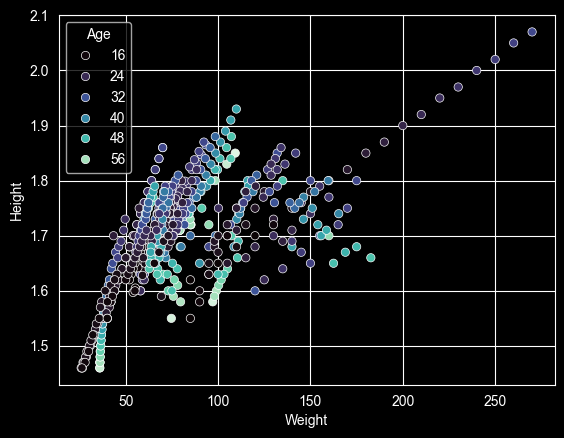

In [8]:
pl.figure()
sns.scatterplot(x='Weight',y='Height',data=data,hue='Age',palette='mako')

<Axes: xlabel='Weight', ylabel='Height'>

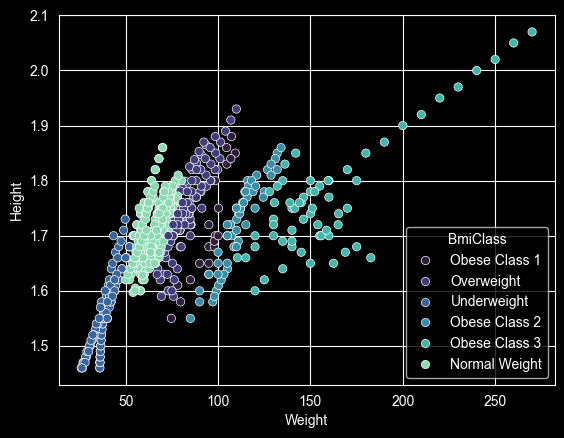

In [9]:
pl.figure()
sns.scatterplot(x='Weight',y='Height',data=data,hue='BmiClass',palette='mako')

In [10]:
from sklearn.preprocessing import LabelEncoder

gender_encoder = LabelEncoder()
class_encoder = LabelEncoder()

data["Gender"] = gender_encoder.fit_transform(data["Gender"])
data["BmiClass"] = class_encoder.fit_transform(data["BmiClass"])

<Axes: >

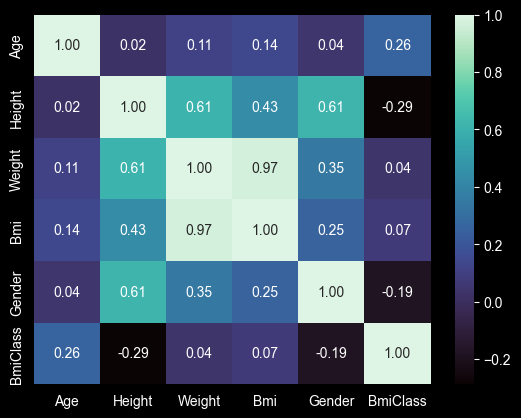

In [11]:
correlation = data.corr()
sns.heatmap(correlation, annot=True,cmap='mako',fmt='.2f')

<Figure size 640x480 with 0 Axes>

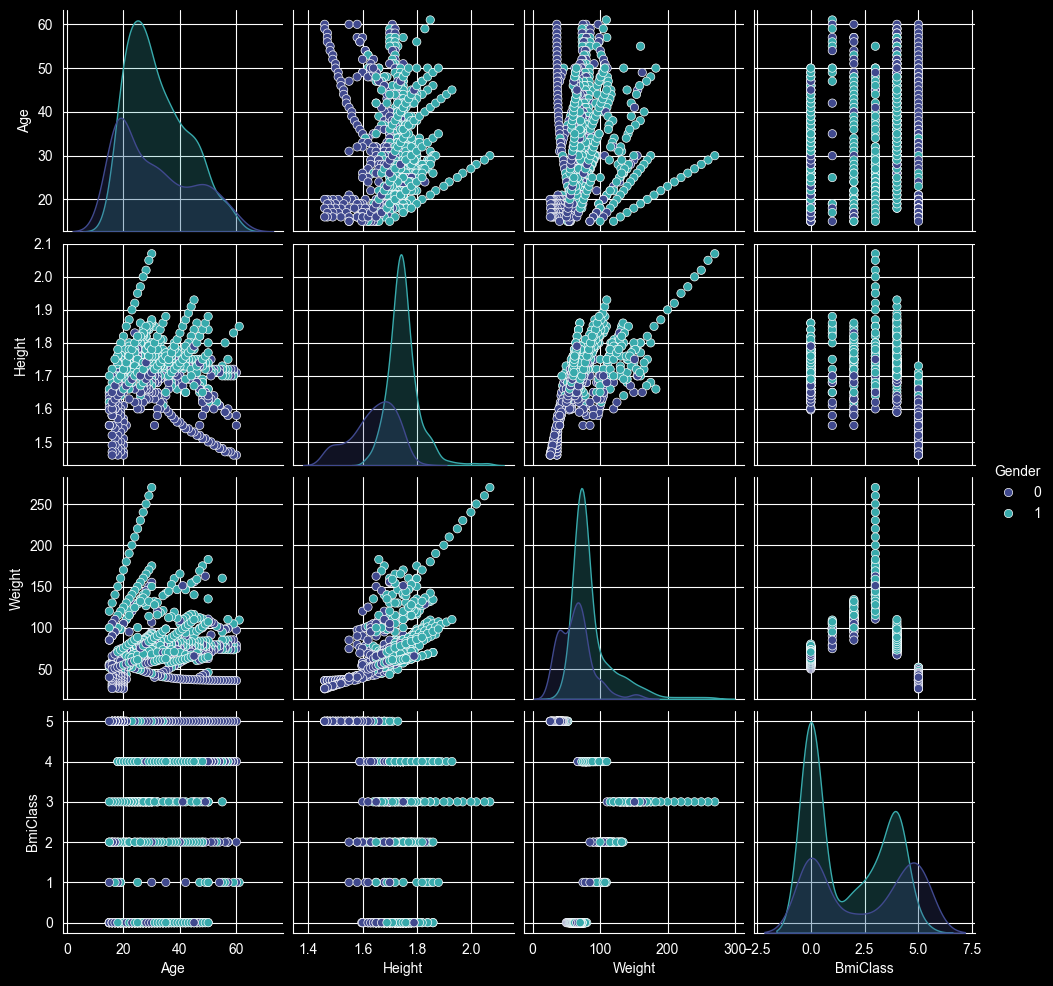

In [12]:
pl.figure()
sns.pairplot(data[["Age", "Height", "Weight", "Gender", "BmiClass"]],palette='mako',hue="Gender")

<Figure size 640x480 with 0 Axes>

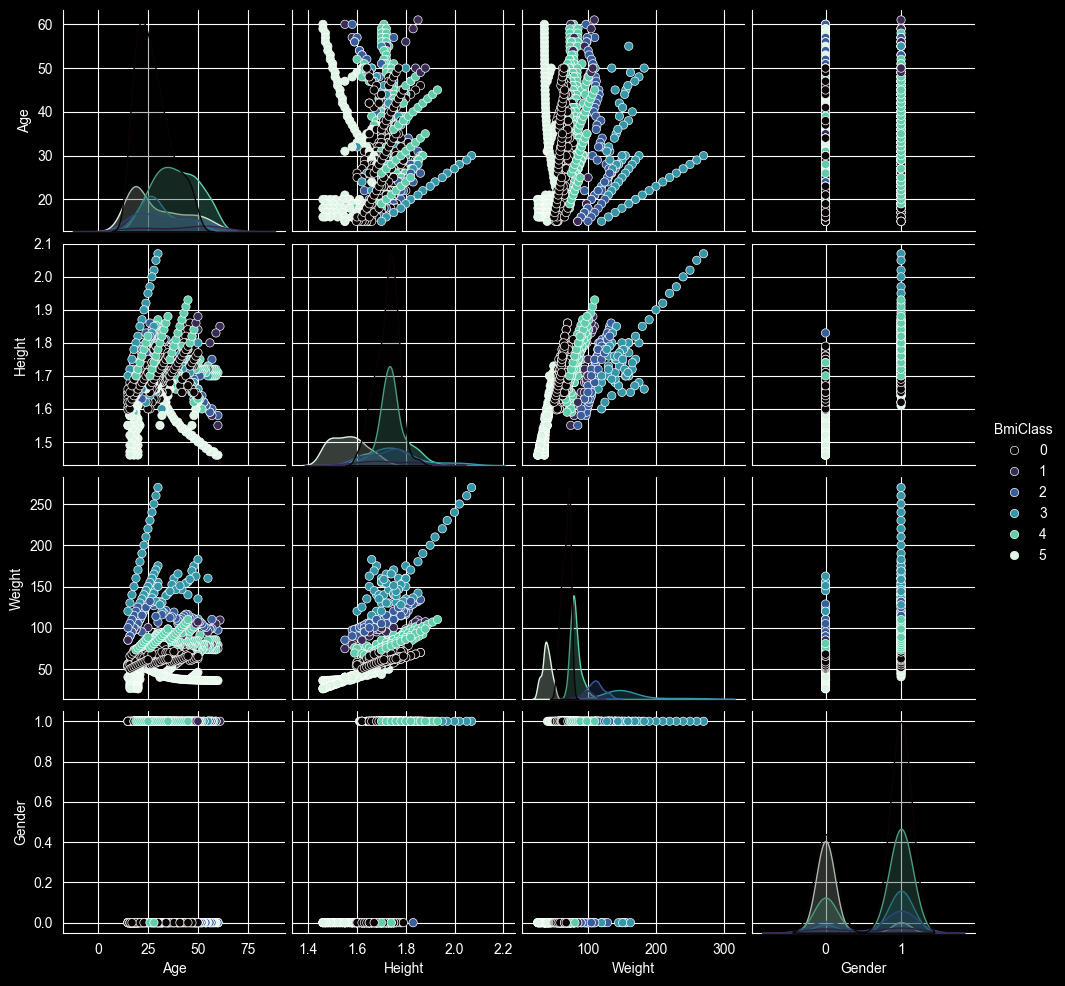

In [13]:
pl.figure()
sns.pairplot(
    data[["Age", "Height", "Weight", "Gender", "BmiClass"]],
    hue="BmiClass",
    palette='mako',
)

In [14]:
#decision tree

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
x = data[["Gender", "Age", "Height", "Weight"]]
y = data["BmiClass"]

In [17]:
from sklearn.ensemble import RandomForestClassifier

In [18]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42,stratify=y)

In [19]:
from imblearn.over_sampling import SMOTE
oversampling = SMOTE(random_state=42)
x_train, y_train = oversampling.fit_resample(x_train, y_train)

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [21]:
forest = RandomForestClassifier(criterion='entropy',n_estimators=100,random_state=42)
forest.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `met

In [22]:
import numpy as np
predict=forest.predict(x_test)
prediction = forest.predict(np.array([[0,20,164,68]]))
print(prediction)

[3]


In [23]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score

In [24]:
print(f"Accuracy : {accuracy_score(y_test,predict)*100}%")
print(f"Precision :{precision_score(y_test,predict,average="weighted")*100}%")

Accuracy : 96.23655913978494%
Precision :96.6973886328725%


In [27]:
import pickle

# Save Random Forest model
with open("random_forest.pkl", "wb") as file:
    pickle.dump(forest, file)

# Save Gender Label Encoder
with open("gender_encoder.pkl", "wb") as file:
    pickle.dump(gender_encoder, file)

# Save BMI Class Label Encoder
with open("class_encoder.pkl", "wb") as file:
    pickle.dump(class_encoder, file)

print("Model and encoders saved successfully!")

Model and encoders saved successfully!
